In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from config import DATA_DIR, CHARTS_DIR

In [3]:
print("Loading data to RAM...")
csv_file_path = DATA_DIR / 'processed_data.csv'

df = pd.read_csv(csv_file_path)
print("Data loaded successfully!")
#print(df.head(5))

Loading data to RAM...
Data loaded successfully!


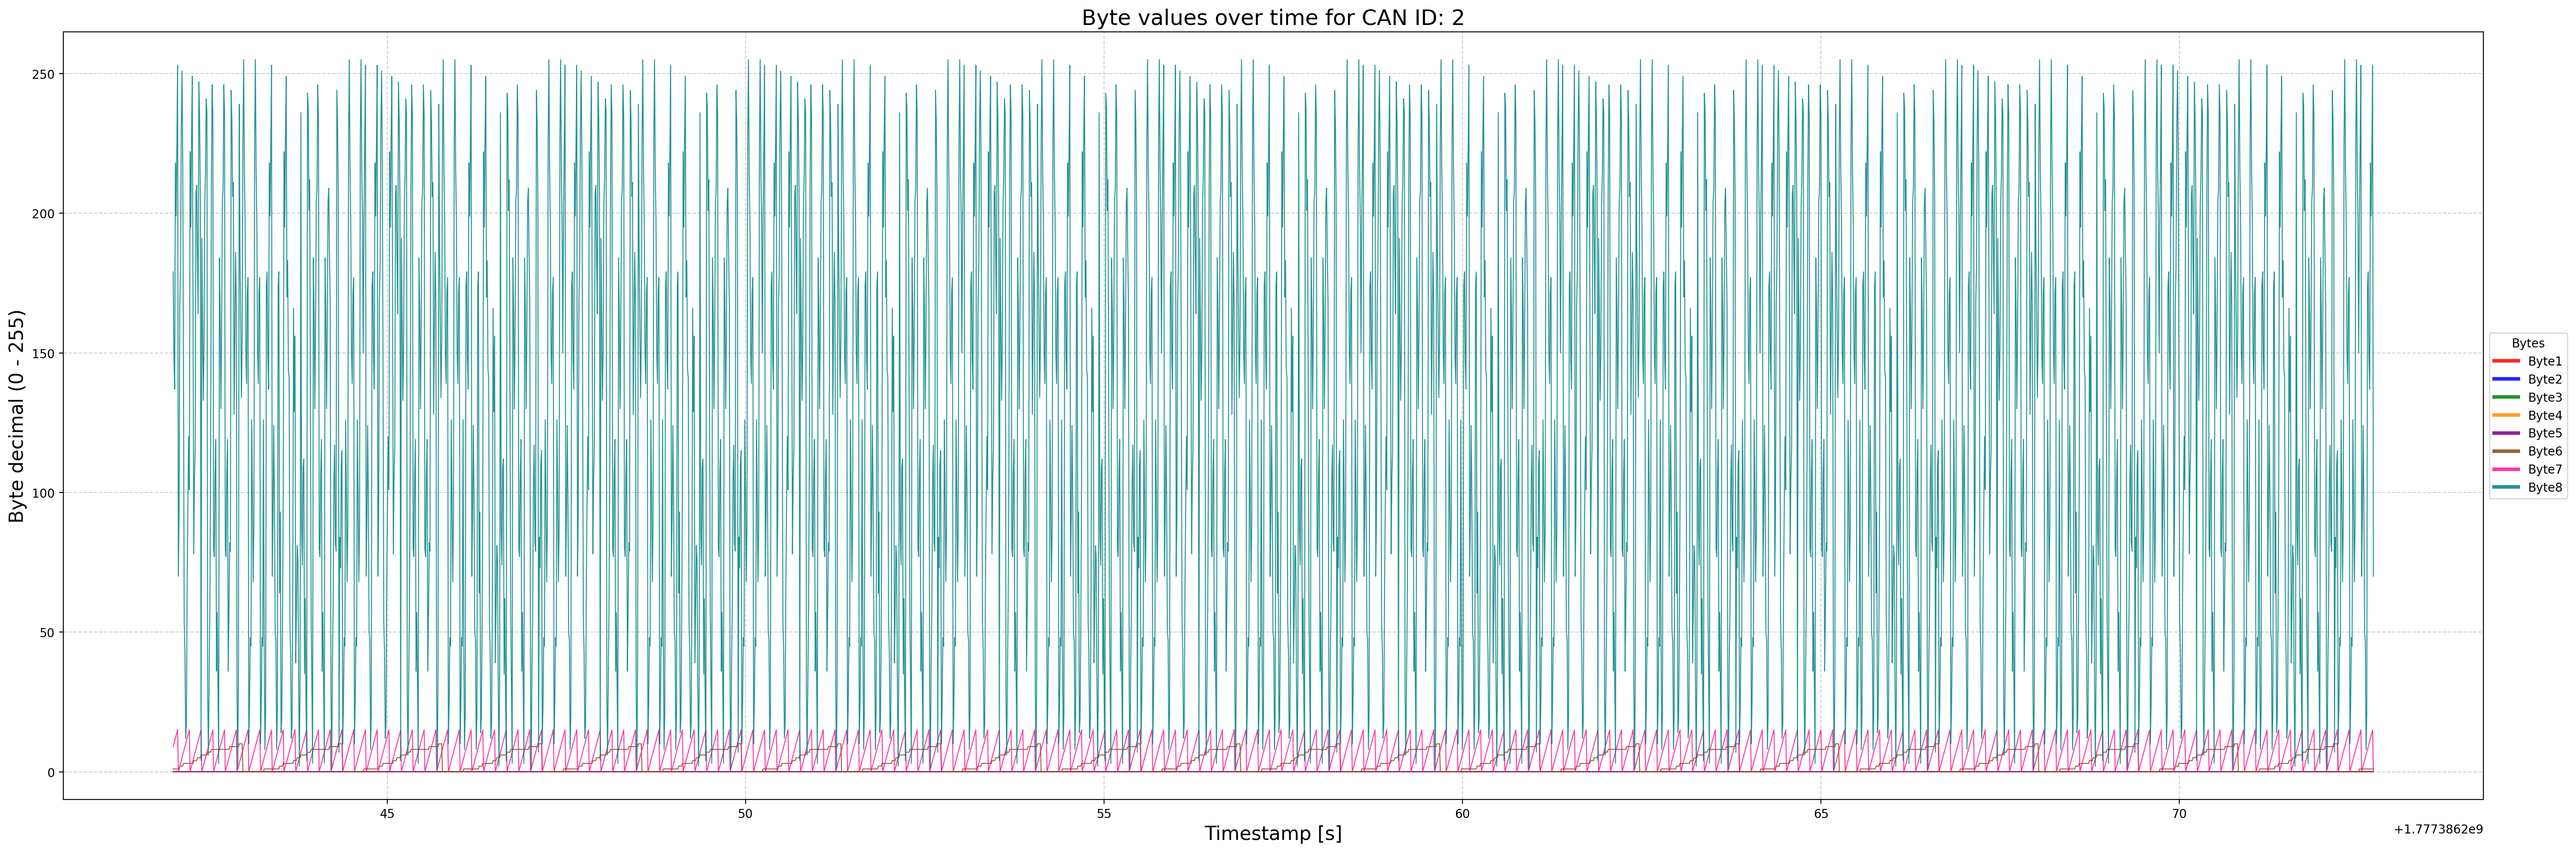

In [6]:
TARGET_CAN_ID = 2
FRAMES_LIMIT = 3000

byte_cols = [f'Byte{i}' for i in range(1, 9)]
colors = ['red', 'blue', 'green', 'darkorange', 'purple', 'saddlebrown', 'deeppink', 'teal']

if str(TARGET_CAN_ID).lower() == 'all':
    target_ids = sorted(df['CAN_ID'].unique())
else:
    target_ids = [TARGET_CAN_ID]

for can_id in target_ids:
    df_mod = df[df['CAN_ID'] == can_id].sort_values(by='Timestamp')

    if FRAMES_LIMIT > 0:
        df_mod = df_mod.head(FRAMES_LIMIT)

    if len(df_mod) < 10:
        continue

    plt.figure(figsize=(30, 10), dpi=200)

    for byte_name, color in zip(byte_cols, colors):
        plt.plot(df_mod['Timestamp'], df_mod[byte_name], label=byte_name, color=color, linewidth=0.8, alpha=0.85)

    plt.title(f'Byte values over time for CAN ID: {can_id}', fontsize=18)
    plt.xlabel('Timestamp [s]', fontsize=16)
    plt.ylabel('Byte decimal (0 - 255)', fontsize=16)
    plt.ylim(-10, 265)
    plt.grid(True, linestyle='--', alpha=0.6)

    leg = plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), title="Bytes")
    for line in leg.get_lines():
        line.set_linewidth(3.0)

    plt.tight_layout()
    #plt.savefig(f'{CHARTS_DIR}/head/head_{can_id}.png')
    plt.show()